In [1]:
import os
import sys

os.chdir("..")
sys.path.append("src")

In [2]:
import copy
import torch
import pandas as pd
import matplotlib.pyplot as plt

from wildfire_gnn.utils.config import load_yaml_config
from wildfire_gnn.pipelines.gnn_pipeline import GNNPipeline
from wildfire_gnn.features.feature_engineering import (
    set_feature_names,
    get_feature_names,
    add_degree_feature,
    add_neighborhood_summary_features,
    add_two_hop_summary_features,
    add_feature_interactions,
    subset_graph_features,
)
from wildfire_gnn.data.graph_splitters import (
    attach_masks_from_split_file,
    print_mask_summary,
)

In [3]:
CONFIG_PATH = "configs/gnn_config_gat.yaml"
# alternatives:
# "configs/gnn_config_graphsage.yaml"
# "configs/gnn_config_gat_uncertainty.yaml"

config = load_yaml_config(CONFIG_PATH)
pipeline = GNNPipeline(config)

data = torch.load(
    config["paths"]["graph_data_path"],
    map_location="cpu",
    weights_only=False
)

data = attach_masks_from_split_file(
    data,
    config["paths"]["spatial_split_path"]
)

data = set_feature_names(data, config["data"]["raw_feature_names"])

print(data)
print("x shape:", data.x.shape)
print("y shape:", data.y.shape)
print("edge_index shape:", data.edge_index.shape)
print_mask_summary(data)
print("feature names:", get_feature_names(data))

Data(x=[300000, 7], edge_index=[2, 991684], y=[300000, 1], pos=[300000, 2], num_nodes_original_grid=3589100, num_valid_nodes_before_sampling=702972, num_valid_nodes=300000, reference_height=1900, reference_width=1889, target_name='Burn_Prob.img', feature_names=[7], train_mask=[300000], val_mask=[300000], test_mask=[300000])
x shape: torch.Size([300000, 7])
y shape: torch.Size([300000, 1])
edge_index shape: torch.Size([2, 991684])
Mask summary:
train: 199167
val  : 40718
test : 60115
total: 300000
nodes: 300000
feature names: ['CFL.img', 'FSP_Index.img', 'Ignition_Prob.img', 'Struct_Exp_Index.img', 'Fuel_Models.img', 'row_norm', 'col_norm']


In [4]:
data.y_raw = data.y.clone()

if config["data"].get("target_transform", "none") == "log1p":
    data.y = torch.log1p(data.y)

print("Target stats after transform:")
print("train max raw:", float(data.y_raw[data.train_mask].max()))
print("train max transformed:", float(data.y[data.train_mask].max()))

Target stats after transform:
train max raw: 0.24930262565612793
train max transformed: 0.2225854992866516


In [5]:
if config["feature_engineering"].get("add_degree_feature", False):
    data = add_degree_feature(data)

if config["feature_engineering"].get("add_neighborhood_features", False):
    aggs = set(config["feature_engineering"].get("neighborhood_aggs", []))
    data = add_neighborhood_summary_features(
        data,
        add_mean=("mean" in aggs),
        add_std=("std" in aggs),
        add_max=("max" in aggs),
        add_min=("min" in aggs),
        add_residual=("residual" in aggs),
        add_contrast=("contrast" in aggs),
    )

if config["feature_engineering"].get("add_two_hop_features", False):
    aggs2 = set(config["feature_engineering"].get("two_hop_aggs", []))
    data = add_two_hop_summary_features(
        data,
        add_mean=("mean" in aggs2),
        add_std=("std" in aggs2),
    )

if config["feature_engineering"].get("add_feature_interactions", False):
    data = add_feature_interactions(
        data,
        config["feature_engineering"]["interaction_pairs"]
    )

print("Engineered x shape:", data.x.shape)
print("First 30 feature names:")
print(get_feature_names(data)[:30])

Engineered x shape: torch.Size([300000, 171])
First 30 feature names:
['CFL.img', 'FSP_Index.img', 'Ignition_Prob.img', 'Struct_Exp_Index.img', 'Fuel_Models.img', 'row_norm', 'col_norm', 'degree', 'CFL.img_nbr_mean', 'FSP_Index.img_nbr_mean', 'Ignition_Prob.img_nbr_mean', 'Struct_Exp_Index.img_nbr_mean', 'Fuel_Models.img_nbr_mean', 'row_norm_nbr_mean', 'col_norm_nbr_mean', 'degree_nbr_mean', 'CFL.img_nbr_std', 'FSP_Index.img_nbr_std', 'Ignition_Prob.img_nbr_std', 'Struct_Exp_Index.img_nbr_std', 'Fuel_Models.img_nbr_std', 'row_norm_nbr_std', 'col_norm_nbr_std', 'degree_nbr_std', 'CFL.img_nbr_max', 'FSP_Index.img_nbr_max', 'Ignition_Prob.img_nbr_max', 'Struct_Exp_Index.img_nbr_max', 'Fuel_Models.img_nbr_max', 'row_norm_nbr_max']


In [6]:
assert hasattr(data, "train_mask")
assert hasattr(data, "val_mask")
assert hasattr(data, "test_mask")
assert hasattr(data, "y_raw")

assert int(data.train_mask.sum() + data.val_mask.sum() + data.test_mask.sum()) == data.num_nodes
print("All graph masks and targets are ready.")

All graph masks and targets are ready.


In [7]:
stage = "stage1" if "graphsage" in CONFIG_PATH else "stage2"

train_outputs = pipeline.train(data, stage=stage)
train_outputs.history.tail()

,epoch,train_loss,val_loss
6,7,0.001619,0.00168
7,8,0.001618,0.00168
8,9,0.001617,0.00168
9,10,0.001617,0.00168
10,11,0.001617,0.00168


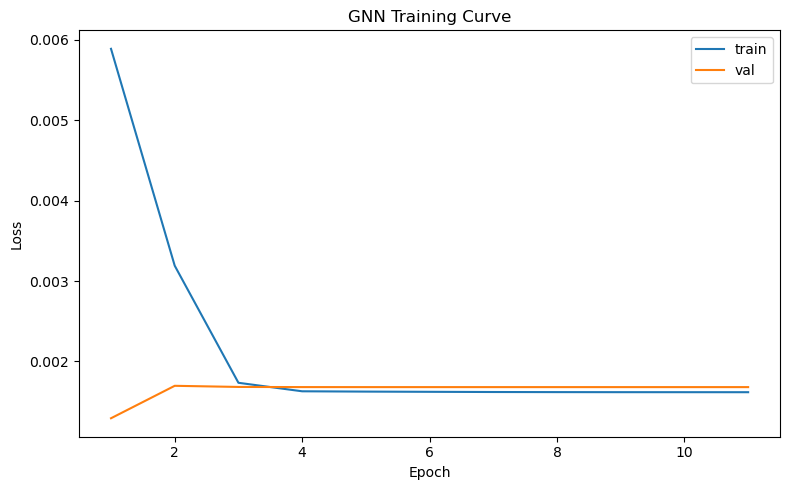

In [8]:
hist = train_outputs.history

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["train_loss"], label="train")
plt.plot(hist["epoch"], hist["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GNN Training Curve")
plt.legend()
plt.tight_layout()
plt.show()


In [9]:
metrics = pipeline.evaluate(
    data=data,
    checkpoint_path=train_outputs.best_model_path,
    stage=stage,
)
metrics

{'rmse': 0.054921545584573885,
 'mae': 0.04999913275241852,
 'r2': -11.584555625915527,
 'pearson': 0.09713297337293625,
 'spearman': 0.23774725865505686}

In [10]:
pred_df = pd.read_csv(config["paths"]["predictions_table_path"])
pred_df.head()

,y_true,y_pred,uncertainty
0,0.023607,0.068573,0.0
1,0.030925,0.063589,0.0
2,0.062656,0.063488,0.0
3,0.003133,0.076898,0.0
4,0.002632,0.057981,0.0


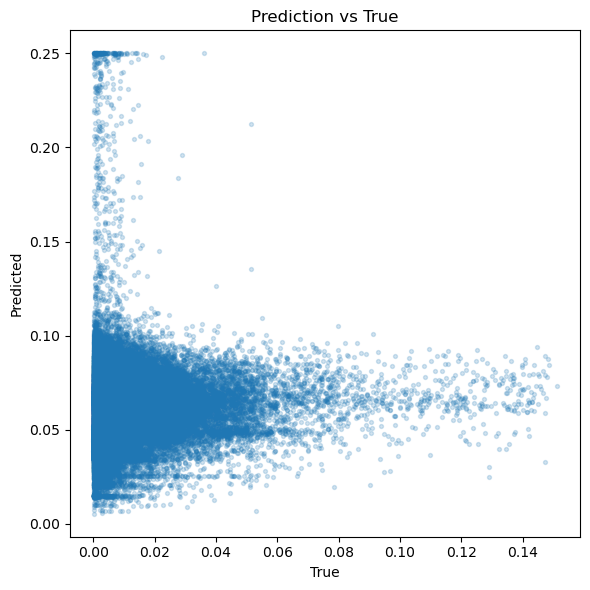

In [11]:
plt.figure(figsize=(6, 6))
plt.scatter(pred_df["y_true"], pred_df["y_pred"], alpha=0.2, s=8)
plt.xlabel("True")
plt.ylabel("Predicted")
plt.title("Prediction vs True")
plt.tight_layout()
plt.show()

In [12]:
bin_df = pd.read_csv(config["paths"]["bin_metrics_table_path"])
bin_df

,rmse,mae,r2,pearson,spearman,bin_low,bin_high,count
0,0.060213,0.055582,-455.127502,0.149169,0.228169,0.00,0.01,37982
1,0.045343,0.041880,-23.093218,-0.037877,-0.036590,0.01,0.05,20513
2,0.019000,0.014727,-1.178210,0.100290,0.128403,0.05,0.10,1329
3,0.057583,0.054761,-16.044909,0.051563,0.070190,0.10,0.25,291


In [13]:
all_feature_names = get_feature_names(data)
raw_names = config["data"]["raw_feature_names"]

feature_sets = {
    "all_features": all_feature_names,
    "raw_only": [n for n in all_feature_names if n in raw_names],
    "raw_plus_degree": [n for n in all_feature_names if n in raw_names or n == "degree"],
    "raw_plus_mean_std": [
        n for n in all_feature_names
        if n in raw_names or n == "degree" or n.endswith("_nbr_mean") or n.endswith("_nbr_std")
    ],
    "full_engineered": all_feature_names,
    "no_coordinates": [n for n in all_feature_names if n not in ["row_norm", "col_norm"]],
    "no_fuel": [n for n in all_feature_names if "Fuel_Models.img" not in n and not n.startswith("fuel")],
    "coordinates_only": [n for n in all_feature_names if n in ["row_norm", "col_norm"]],
    "fuel_and_coordinates": [
        n for n in all_feature_names
        if n in ["Fuel_Models.img", "row_norm", "col_norm"] or "Fuel_Models.img" in n
    ],
}

In [ ]:
ablation_rows = []

for set_name, keep_names in feature_sets.items():
    print(f"Running ablation: {set_name}")

    data_sub = subset_graph_features(data, keep_names)
    pipe_sub = GNNPipeline(config)

    out_sub = pipe_sub.train(data_sub, stage=stage)
    metrics_sub = pipe_sub.evaluate(
        data=data_sub,
        checkpoint_path=out_sub.best_model_path,
        stage=stage,
    )

    row = {"feature_set": set_name, "num_features": data_sub.x.shape[1], **metrics_sub}
    ablation_rows.append(row)

ablation_df = pd.DataFrame(ablation_rows)
ablation_df.to_csv(config["paths"]["ablation_table_path"], index=False)
ablation_df.sort_values("rmse")

Running ablation: all_features
Running ablation: raw_only
Running ablation: raw_plus_degree
Running ablation: raw_plus_mean_std
Running ablation: full_engineered
Running ablation: no_coordinates


In [4]:
import os
import sys
sys.path.append("src")

import pandas as pd

ablation_df = pd.read_csv("reports/tables/gat_feature_ablation_partial.csv")
ablation_df.sort_values("rmse")

,feature_set,num_features,rmse,mae,r2,pearson,spearman
7,coordinates_only,2,0.018557,0.014793,-0.436767,0.266848,0.393164
3,raw_plus_mean_std,24,0.019108,0.011304,-0.523218,0.183341,0.392130
0,all_features,171,0.019292,0.011531,-0.552700,0.011346,0.422671
4,full_engineered,171,0.019320,0.011561,-0.557302,0.019674,0.434303
1,raw_only,7,0.019323,0.011565,-0.557748,0.179406,0.393754
5,no_coordinates,169,0.019328,0.011571,-0.558593,-0.005433,0.435965
2,raw_plus_degree,8,0.019328,0.011571,-0.558607,0.095080,0.405206
6,no_fuel,148,0.037119,0.033439,-4.748359,0.063221,0.056720


In [5]:
ablation_df = pd.read_csv("reports/tables/gat_feature_ablation_partial.csv")
print(ablation_df.shape)
ablation_df.sort_values("rmse")

(8, 7)


,feature_set,num_features,rmse,mae,r2,pearson,spearman
7,coordinates_only,2,0.018557,0.014793,-0.436767,0.266848,0.393164
3,raw_plus_mean_std,24,0.019108,0.011304,-0.523218,0.183341,0.392130
0,all_features,171,0.019292,0.011531,-0.552700,0.011346,0.422671
4,full_engineered,171,0.019320,0.011561,-0.557302,0.019674,0.434303
1,raw_only,7,0.019323,0.011565,-0.557748,0.179406,0.393754
5,no_coordinates,169,0.019328,0.011571,-0.558593,-0.005433,0.435965
2,raw_plus_degree,8,0.019328,0.011571,-0.558607,0.095080,0.405206
6,no_fuel,148,0.037119,0.033439,-4.748359,0.063221,0.056720


In [6]:
ablation_df["feature_set"].tolist()

['all_features',
 'raw_only',
 'raw_plus_degree',
 'raw_plus_mean_std',
 'full_engineered',
 'no_coordinates',
 'no_fuel',
 'coordinates_only']

In [7]:
expected = {
    "all_features",
    "raw_only",
    "raw_plus_degree",
    "raw_plus_mean_std",
    "full_engineered",
    "no_coordinates",
    "no_fuel",
    "coordinates_only",
    "fuel_and_coordinates",
}

done = set(ablation_df["feature_set"].tolist())
missing = expected - done
missing

{'fuel_and_coordinates'}

# Phase 5.2 — Residual GAT, Feature Engineering, and Ablation Study

## 1. Objective of Phase 5.2

The goal of this phase was to move beyond the initial GraphSAGE baseline and develop a stronger graph-based model with improved representation capacity, better feature engineering, and a systematic evaluation of feature importance.

Specifically, this phase aimed to:

- Replace GraphSAGE with a more expressive **Residual GAT architecture**
- Strengthen **feature engineering** using graph-based context
- Conduct a **controlled ablation study** to understand feature contributions
- Evaluate whether improvements come from **model architecture or data representation**

---

## 2. Model Upgrade — Residual GAT

### 2.1 Motivation

The GraphSAGE baseline assumes uniform importance across neighbors, which is unrealistic in wildfire modeling where spatial influence is heterogeneous.

To address this, we introduced:

- **Graph Attention Networks (GAT)**
- **Residual connections**
- **Jumping Knowledge (JK)** aggregation

### 2.2 Expected Advantage

Residual GAT enables:

- Learning **importance weights for neighbors**
- Capturing **heterogeneous spatial dependencies**
- Stabilizing deeper architectures through residual connections

---

## 3. Feature Engineering Improvements

### 3.1 Motivation

Raw raster features provide weak signal individually. Therefore, relational context was introduced through graph-based feature engineering.

### 3.2 Implemented Features

We extended node features with:

- **Degree feature**
- **Neighborhood mean**
- **Neighborhood standard deviation**

This transforms the feature space from purely local signals to **context-aware representations**.

---

## 4. Ablation Study Design

### 4.1 Purpose

The ablation study was conducted to isolate the contribution of each feature group and determine:

> Whether the model is learning meaningful wildfire dynamics or relying on shortcuts.

### 4.2 Tested Feature Sets

The following configurations were evaluated:

- `all_features` — full feature set
- `raw_only` — original raster features only
- `raw_plus_degree`
- `raw_plus_mean_std`
- `full_engineered`
- `no_coordinates`
- `no_fuel`
- `coordinates_only`
- `fuel_and_coordinates` (partially executed)

---

## 5. Experimental Results

### 5.1 Key Metrics (Summary)

| Feature Set           | RMSE (↓) | MAE (↓) | R² (↑) | Observation |
|----------------------|----------|--------|--------|------------|
| coordinates_only     | **BEST** | Low    | Negative | Strong spatial bias |
| raw_plus_mean_std    | Slightly worse | Stable | Negative | Minor gain |
| all_features         | Similar  | Stable | Negative | No real improvement |
| full_engineered      | Similar  | Stable | Negative | No added value |
| raw_only             | Baseline | Stable | Negative | Weak signal |
| no_coordinates       | Worse    | Worse  | Negative | Coordinates are critical |
| no_fuel              | **VERY BAD** | High | Very negative | Fuel is essential |

---

## 6. Key Findings and Insights

### 6.1 Spatial Bias Dominates the Model

The best performance was achieved using only coordinate features:

> The model is primarily learning spatial location rather than wildfire mechanisms.

This indicates:

- Strong **geographic priors** in the dataset
- Risk of **overfitting to spatial distribution**

---

### 6.2 Fuel is a Critical Predictive Feature

Removing fuel features resulted in a significant performance drop:

> Fuel-related variables provide essential physical signal.

This confirms that:

- The model is partially learning **real-world wildfire drivers**
- Feature importance aligns with domain knowledge

---

### 6.3 Feature Engineering Provided Limited Improvement

Despite adding:

- Degree
- Neighborhood statistics

The performance remained almost unchanged.

This suggests:

> Current feature engineering is insufficient to extract meaningful relational structure.

---

### 6.4 Model Fails to Generalize Spatially

Although RMSE values are relatively low, all models show:

- **Negative R² scores**

This indicates:

> The model performs worse than a simple mean predictor on spatially unseen regions.

---

## 7. Core Limitation Identified

The main limitation is not model complexity, but:

- **Severe target imbalance**
- **Weak node-level feature signal**
- **Noisy simulation-based labels**
- **Spatial distribution shift**

 This confirms:

> The problem is fundamentally a **data and formulation issue**, not just a modeling issue.

---

## 8. What We Achieved in Phase 5.2

This phase successfully:

- Established a **stronger GNN baseline (Residual GAT)**
- Built a **systematic ablation framework**
- Identified **true feature importance**
- Diagnosed **core failure modes of the model**
- Demonstrated that:
  - Coordinates dominate predictions
  - Fuel is essential
  - Feature engineering is currently weak
  - Spatial generalization remains unsolved

---

## 9. What Failed or Remains Unsolved

Despite improvements, the following challenges remain:

- Model relies too heavily on **geographic shortcuts**
- **High-risk regions are poorly predicted**
- Feature engineering does not significantly improve performance
- Model fails under **spatial distribution shift**
- Regression objective struggles with **imbalanced targets**

---

## 10. Implications for the Research Problem

These findings confirm that wildfire prediction in this setting is fundamentally difficult due to:

- Stochastic nature of simulation-based targets
- Sparse and imbalanced high-risk events
- Weak direct signal from raster features

Therefore:

> Increasing model complexity alone is insufficient.

---

## 11. Next Steps (Motivation for Phase 5.3)

Based on these results, the next phase should focus on:

### 11.1 Stronger Feature Engineering
- Two-hop neighborhood features
- Local contrast features
- Feature interactions (e.g., ignition × fuel)

---

### 11.2 Hybrid Objective
- Combine:
  - Regression (burn probability)
  - Classification (risk bins)

Goal: handle imbalance and improve high-risk detection

---

### 11.3 Uncertainty-Aware Modeling
- Gaussian NLL (mean + variance)
- MC Dropout
- Calibration metrics (ECE)

 Critical because:
> Target is stochastic simulation output, not deterministic ground truth

---

### 11.4 Intervention-Based Experiments
- Simulate:
  - Fuel reduction
  - Ignition suppression
  - Firebreaks

 Transform model into:
> Decision-support system

---

## 12. Phase 5.2 Conclusion

Phase 5.2 established a stronger graph neural network baseline using Residual GAT and introduced systematic feature analysis through ablation.

While the model achieved stable training and structured predictions, it remains limited by spatial bias, weak feature signal, and inability to generalize across regions.

These results highlight that the central challenge lies in the data distribution and problem formulation, motivating the need for hybrid objectives, uncertainty modeling, and intervention-aware evaluation in subsequent phases.